  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...


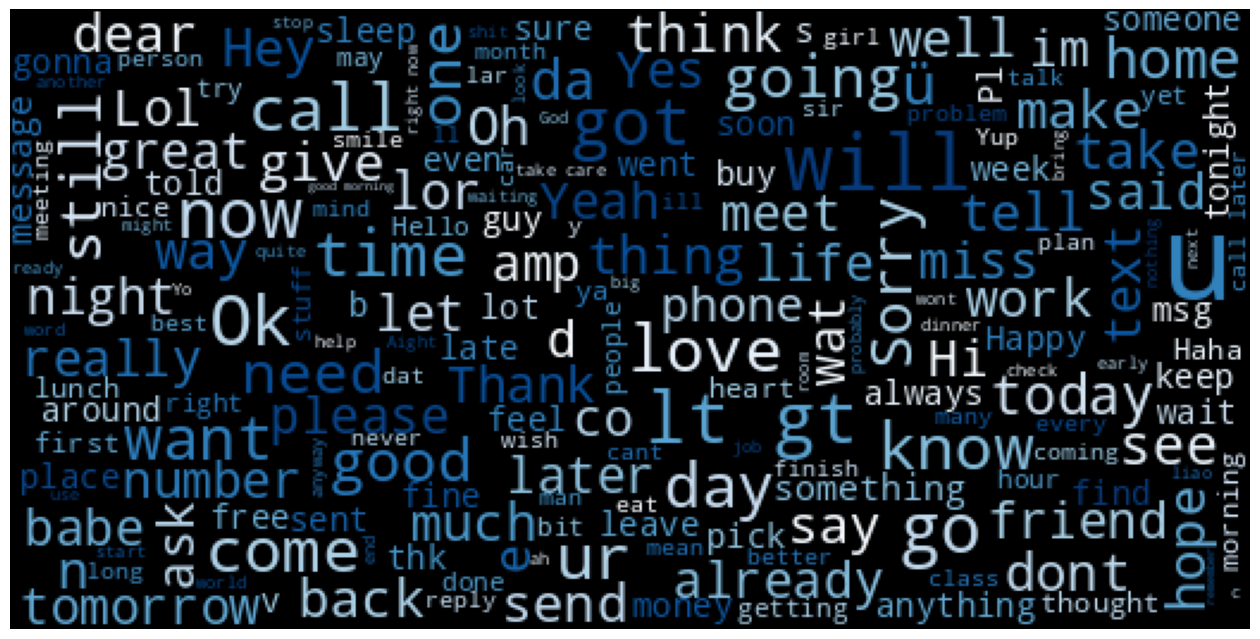

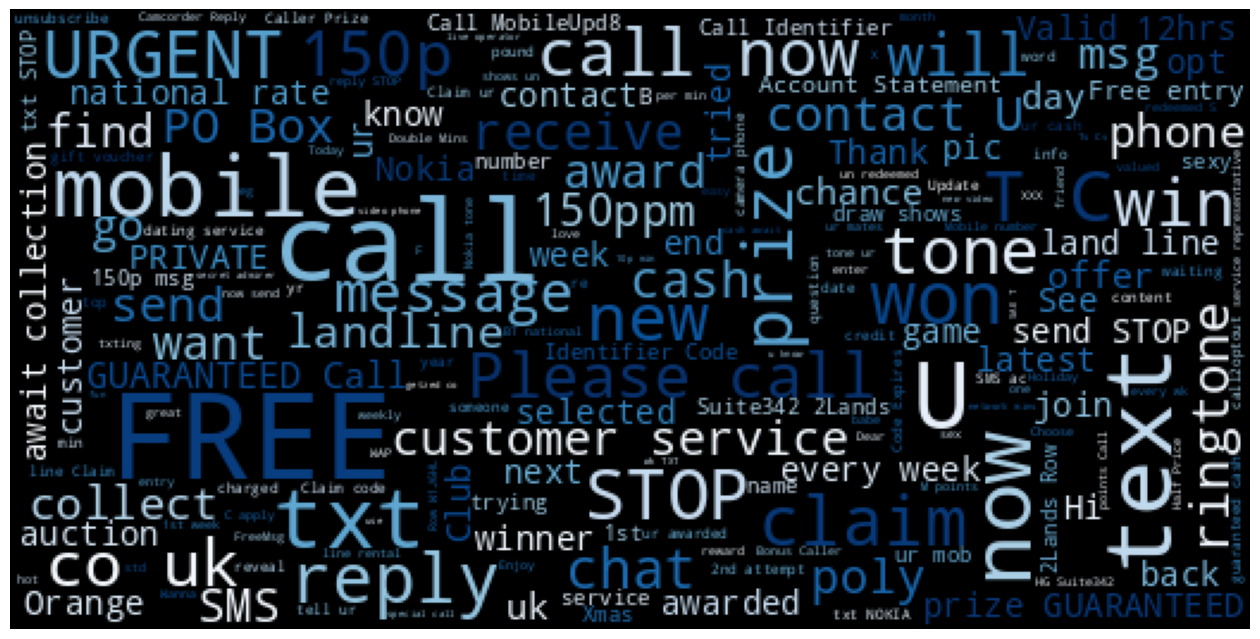

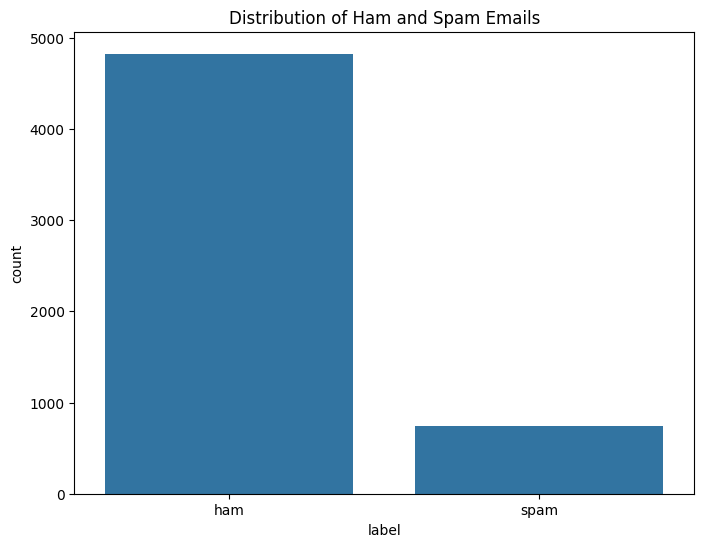

In [3]:

import tensorflow as tf  # Import TensorFlow library
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation
import seaborn as sns
import matplotlib.pyplot as plt  # Import Matplotlib for plotting
from wordcloud import WordCloud, STOPWORDS
%matplotlib inline

from sklearn.model_selection import train_test_split

# Load the SMS spam dataset
file_path = '/content/SMSSpamCollection.txt'  # Path to the dataset
messages = pd.read_csv(file_path, sep='\t', names=["label",
"message"])

print(messages.head(3))

#visualization
ham_msg = messages[messages.label == 'ham']
spam_msg = messages[messages.label == 'spam']
ham_msg_text = " ".join(ham_msg.message.to_numpy())   #join to create string
spam_msg_text = " ".join(spam_msg.message.to_numpy())

# Generate and display word cloud for ham messages
ham_msg_cloud = WordCloud(width=520, height=260, stopwords=STOPWORDS,
max_font_size=50,background_color="black",colormap='Blues').generate(ham_msg_text)
plt.figure(figsize=(16, 10))  # Set the figure size for the plot
plt.imshow(ham_msg_cloud)  # Display the word cloud
plt.axis('off')  # Turn off axis labels
plt.show()  # Show the plot

# Generate and display word cloud for spam messages
spam_msg_cloud = WordCloud(width=520, height=260,
stopwords=STOPWORDS, max_font_size=50, background_color="black",colormap='Blues').generate(spam_msg_text)
plt.figure(figsize=(16, 10))  # Set the figure size for the plot
plt.imshow(spam_msg_cloud)  # Display the word cloud
plt.axis('off')  # Turn off axis labels
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=messages)
plt.title('Distribution of Ham and Spam Emails')
plt.show()


In [4]:
# Downsample ham messages to balance the dataset
ham_msg_df = ham_msg.sample(n=len(spam_msg), random_state=44)
msg_df = pd.concat([ham_msg_df, spam_msg])

# Add a text length column
msg_df['text_length'] = msg_df['message'].apply(len)

# Calculate average text length by label
labels = msg_df.groupby('label')['text_length'].mean()
print(labels)  # Print average lengths for inspection

# Encode labels: 0 for ham, 1 for spam
msg_df['msg_type'] = msg_df['label'].map({'ham': 0, 'spam': 1})
msg_label = msg_df['msg_type'].values

# Split data into training and testing sets (80% train, 20% test)
train_msg, test_msg, train_labels, test_labels = train_test_split(
    msg_df['message'], msg_label, test_size=0.2, random_state=434
)
print("Count of ham messages after downsampling:", len(ham_msg_df))
print("Count of spam messages:", len(spam_msg))

label
ham      73.238286
spam    138.670683
Name: text_length, dtype: float64
Count of ham messages after downsampling: 747
Count of spam messages: 747


In [5]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 50
padding_type = "post"
oov_tok = "<OOV>"  # Out-of-vocabulary token
vocab_size = 500  # Maximum number of unique words to keep

# Tokenization of text data
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_msg)

# Get the word index and total number of unique tokens
word_index = tokenizer.word_index  # Get the word index mapping
tot_words = len(word_index)  # Get the total number of unique tokens
print(f'There are {tot_words} unique tokens in training data.')

# Convert text to sequences and pad them
training_sequences = tokenizer.texts_to_sequences(train_msg)
training_padded = pad_sequences(training_sequences, maxlen=max_len,
padding=padding_type)
testing_sequences = tokenizer.texts_to_sequences(test_msg)
testing_padded = pad_sequences(testing_sequences, maxlen=max_len,
padding=padding_type)

There are 4169 unique tokens in training data.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout  # Import layers for the model

# Parameters for the Dense model
embedding_dim = 16  # Dimension of the embedding vector
drop_value = 0.2  # Dropout rate to prevent overfitting
n_dense = 24  # Number of neurons in the dense layer

# Define the Dense model architecture
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),  # embedding layer
    GlobalAveragePooling1D(),                                                        # global average pooling
    Dense(n_dense, activation='relu'),                                              # dense layer with ReLU
    Dropout(drop_value),                                                             # dropout layer
    Dense(1, activation='sigmoid')                                                  # output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
num_epochs = 30
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Train the model
history = model.fit(training_padded, train_labels,
epochs=num_epochs,  # Fit the model on the training data
validation_data=(testing_padded, test_labels), callbacks=[early_stop], verbose=2)

Epoch 1/30
38/38 - 3s - 72ms/step - accuracy: 0.7163 - loss: 0.6799 - val_accuracy: 0.8027 - val_loss: 0.6636
Epoch 2/30
38/38 - 0s - 4ms/step - accuracy: 0.8209 - loss: 0.6312 - val_accuracy: 0.8060 - val_loss: 0.6083
Epoch 3/30
38/38 - 0s - 4ms/step - accuracy: 0.8301 - loss: 0.5541 - val_accuracy: 0.8161 - val_loss: 0.5326
Epoch 4/30
38/38 - 0s - 5ms/step - accuracy: 0.8502 - loss: 0.4701 - val_accuracy: 0.8261 - val_loss: 0.4629
Epoch 5/30
38/38 - 0s - 4ms/step - accuracy: 0.8703 - loss: 0.3969 - val_accuracy: 0.8428 - val_loss: 0.4005
Epoch 6/30
38/38 - 0s - 4ms/step - accuracy: 0.8929 - loss: 0.3360 - val_accuracy: 0.8629 - val_loss: 0.3409
Epoch 7/30
38/38 - 0s - 8ms/step - accuracy: 0.9021 - loss: 0.2871 - val_accuracy: 0.8930 - val_loss: 0.2918
Epoch 8/30
38/38 - 0s - 4ms/step - accuracy: 0.9188 - loss: 0.2409 - val_accuracy: 0.8930 - val_loss: 0.2560
Epoch 9/30
38/38 - 0s - 4ms/step - accuracy: 0.9397 - loss: 0.2158 - val_accuracy: 0.9064 - val_loss: 0.2397
Epoch 10/30
38/38 

In [ ]:
loss, accuracy = model.evaluate(testing_padded, test_labels)
print(f'Test Loss: {loss}')  # Print test loss
print(f'Test Accuracy: {accuracy}')  # Print test accuracy

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9432 - loss: 0.1206 
Test Loss: 0.12951306998729706
Test Accuracy: 0.9397993087768555


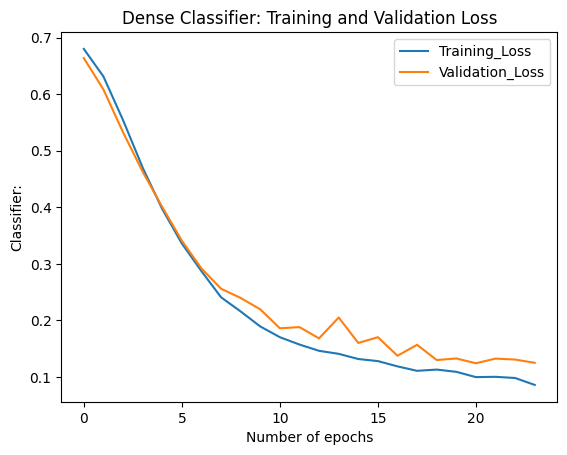

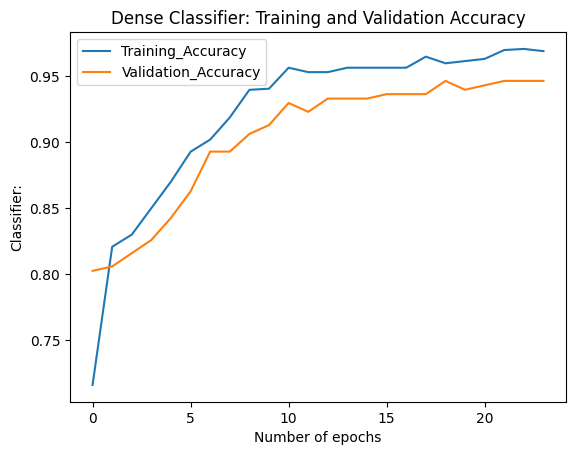

In [8]:
metrics = pd.DataFrame(history.history)
metrics.rename(columns={'loss': 'Training_Loss', 'accuracy':
'Training_Accuracy',
'val_loss': 'Validation_Loss',
'val_accuracy': 'Validation_Accuracy'}, inplace=True)  # Rename columns
# Function to plot training and validation metrics
def plot_graphs(var1, var2, title):
  metrics[[var1, var2]].plot()  # Plot the specified metrics
  plt.title(title)  # Set the title of the plot
  plt.xlabel('Number of epochs')  # Set x-axis label
  plt.ylabel(title.split()[1])  # Set y-axis label
  plt.legend([var1, var2])  # Add a legend
  plt.show()  # Show the plot

# Plot training and validation loss and accuracy
plot_graphs('Training_Loss', 'Validation_Loss', 'Dense Classifier: Training and Validation Loss')  # Plot loss
plot_graphs('Training_Accuracy', 'Validation_Accuracy', 'Dense Classifier: Training and Validation Accuracy')  # Plot accuracy

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

n_lstm = 20  # Number of LSTM units
drop_lstm = 0.2  # Dropout rate for LSTM

# Define LSTM model architecture
model1 = Sequential()  # Start a new Sequential model
model1.add(Embedding(vocab_size, embedding_dim,
input_length=max_len))  # Add embedding layer
model1.add(LSTM(n_lstm, dropout=drop_lstm, return_sequences=True))
model1.add(LSTM(n_lstm, dropout=drop_lstm))  # Add second LSTM layer
model1.add(Dense(1, activation='sigmoid'))

# Compile the LSTM model
model1.compile(loss='binary_crossentropy', optimizer='adam',
metrics=['accuracy'])  # Compile the model

# Train the LSTM model
history1 = model1.fit(training_padded, train_labels, epochs=num_epochs,validation_data=(testing_padded, test_labels),callbacks=[early_stop], verbose=2)

Epoch 1/30
38/38 - 6s - 160ms/step - accuracy: 0.4762 - loss: 0.6937 - val_accuracy: 0.4716 - val_loss: 0.6914
Epoch 2/30
38/38 - 1s - 33ms/step - accuracy: 0.7506 - loss: 0.5530 - val_accuracy: 0.8662 - val_loss: 0.3739
Epoch 3/30
38/38 - 1s - 33ms/step - accuracy: 0.9230 - loss: 0.2532 - val_accuracy: 0.9164 - val_loss: 0.2409
Epoch 4/30
38/38 - 1s - 32ms/step - accuracy: 0.9481 - loss: 0.1879 - val_accuracy: 0.9666 - val_loss: 0.1609
Epoch 5/30
38/38 - 2s - 42ms/step - accuracy: 0.9531 - loss: 0.1670 - val_accuracy: 0.9431 - val_loss: 0.1972
Epoch 6/30
38/38 - 2s - 50ms/step - accuracy: 0.9582 - loss: 0.1420 - val_accuracy: 0.9030 - val_loss: 0.2763
Epoch 7/30
38/38 - 1s - 32ms/step - accuracy: 0.9674 - loss: 0.1310 - val_accuracy: 0.9431 - val_loss: 0.1548
Epoch 8/30
38/38 - 1s - 35ms/step - accuracy: 0.9649 - loss: 0.1189 - val_accuracy: 0.9699 - val_loss: 0.0902
Epoch 9/30
38/38 - 1s - 32ms/step - accuracy: 0.9732 - loss: 0.0958 - val_accuracy: 0.9766 - val_loss: 0.0812
Epoch 10/

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9689 - loss: 0.1360
LSTM Test Loss: 0.11600836366415024
LSTM Test Accuracy: 0.9698996543884277


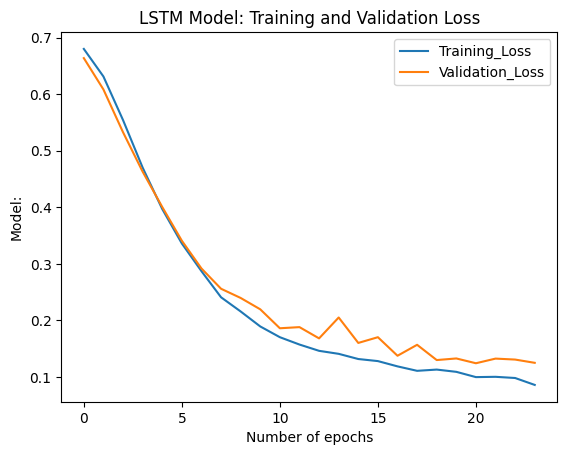

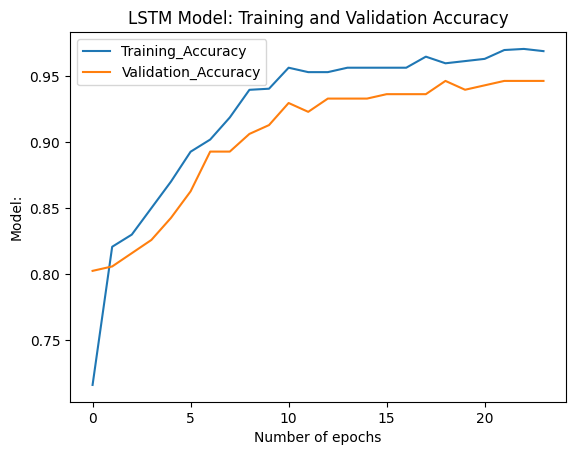

In [11]:
loss1, accuracy1 = model1.evaluate(testing_padded, test_labels)
print(f'LSTM Test Loss: {loss1}')  # Print LSTM test loss
print(f'LSTM Test Accuracy: {accuracy1}')  # Print LSTM test accuracy
# Create a dataframe for LSTM metrics
metrics1 = pd.DataFrame(history1.history)
# Rename columns for clarity
metrics1.rename(columns={'loss': 'Training_Loss', 'accuracy':
'Training_Accuracy',
'val_loss': 'Validation_Loss',
'val_accuracy': 'Validation_Accuracy'})  # Rename columns
# Plot LSTM metrics
plot_graphs('Training_Loss', 'Validation_Loss', 'LSTM Model: Training and Validation Loss')  # Plot loss for LSTM
plot_graphs('Training_Accuracy', 'Validation_Accuracy', 'LSTM Model: Training and Validation Accuracy')

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

model2 = Sequential()  # Start a new Sequential model
model2.add(Embedding(vocab_size, embedding_dim,
input_length=max_len))  # Add embedding layer
model2.add(Bidirectional(LSTM(n_lstm, dropout=drop_lstm)))
model2.add(Dense(1, activation='sigmoid'))
# Compile the Bidirectional LSTM model
model2.compile(loss='binary_crossentropy', optimizer='adam',
metrics=['accuracy'])  # Compile the model

# Train the Bidirectional LSTM model
history2 = model2.fit(training_padded, train_labels, epochs=num_epochs,validation_data=(testing_padded, test_labels),callbacks=[early_stop], verbose=2)

Epoch 1/30
38/38 - 6s - 147ms/step - accuracy: 0.7506 - loss: 0.6721 - val_accuracy: 0.7625 - val_loss: 0.6029
Epoch 2/30
38/38 - 2s - 65ms/step - accuracy: 0.8502 - loss: 0.4635 - val_accuracy: 0.8428 - val_loss: 0.3826
Epoch 3/30
38/38 - 1s - 36ms/step - accuracy: 0.8770 - loss: 0.3228 - val_accuracy: 0.9064 - val_loss: 0.2649
Epoch 4/30
38/38 - 2s - 63ms/step - accuracy: 0.9406 - loss: 0.1867 - val_accuracy: 0.9264 - val_loss: 0.1674
Epoch 5/30
38/38 - 1s - 31ms/step - accuracy: 0.9623 - loss: 0.1203 - val_accuracy: 0.9465 - val_loss: 0.1372
Epoch 6/30
38/38 - 1s - 28ms/step - accuracy: 0.9598 - loss: 0.1267 - val_accuracy: 0.9298 - val_loss: 0.2017
Epoch 7/30
38/38 - 1s - 33ms/step - accuracy: 0.9707 - loss: 0.0973 - val_accuracy: 0.9632 - val_loss: 0.0959
Epoch 8/30
38/38 - 1s - 28ms/step - accuracy: 0.9732 - loss: 0.0825 - val_accuracy: 0.9431 - val_loss: 0.1333
Epoch 9/30
38/38 - 1s - 30ms/step - accuracy: 0.9757 - loss: 0.0765 - val_accuracy: 0.9599 - val_loss: 0.1033
Epoch 10/

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9520 - loss: 0.1465
Bi-LSTM Test Loss: 0.1191118136048317
Bi-LSTM Test Accuracy: 0.9632107019424438


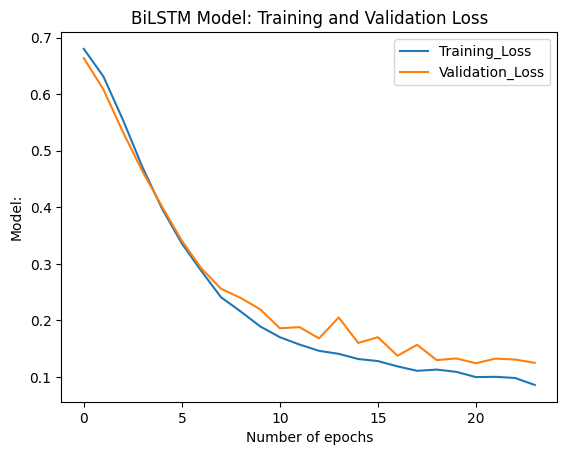

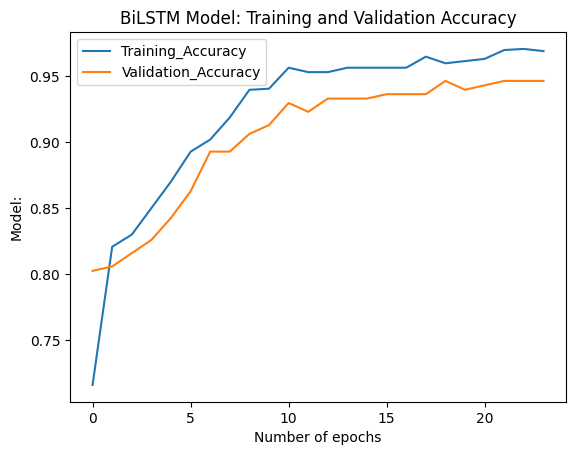

In [17]:
loss2, accuracy2 = model2.evaluate(testing_padded, test_labels)
print(f'Bi-LSTM Test Loss: {loss2}')  # Print Bi-LSTM test loss
print(f'Bi-LSTM Test Accuracy: {accuracy2}')
# Create a dataframe for Bidirectional LSTM metrics
metrics2 = pd.DataFrame(history2.history)

# Rename columns for clarity
metrics2.rename(columns={'loss': 'Training_Loss', 'accuracy':
'Training_Accuracy', 'val_loss': 'Validation_Loss',
'val_accuracy': 'Validation_Accuracy'})  # Rename columns

# Plot Bidirectional LSTM metrics
plot_graphs('Training_Loss', 'Validation_Loss', 'BiLSTM Model: Training and Validation Loss')  # Plot loss for Bi-LSTM
plot_graphs('Training_Accuracy', 'Validation_Accuracy', 'BiLSTM Model: Training and Validation Accuracy')

In [18]:
print(f"Dense architecture loss and accuracy: {model.evaluate(testing_padded, test_labels)}")
print(f"LSTM architecture loss and accuracy: {model1.evaluate(testing_padded, test_labels)}")
print(f"Bi-LSTM architecture loss and accuracy: {model2.evaluate(testing_padded, test_labels)}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9473 - loss: 0.1168 
Dense architecture loss and accuracy: [0.12503646314144135, 0.9464883208274841]
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9689 - loss: 0.1360
LSTM architecture loss and accuracy: [0.11600836366415024, 0.9698996543884277]
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9520 - loss: 0.1465
Bi-LSTM architecture loss and accuracy: [0.1191118136048317, 0.9632107019424438]


In [21]:
predict_msg = [ "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",
    "Ok lar... Joking wif u oni...",
    "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
]

# Function to predict spam
def predict_spam(predict_msg):
    new_seq = tokenizer.texts_to_sequences(predict_msg)
    padded = pad_sequences(new_seq, maxlen=max_len, padding='post',
truncating='post')  # Pad sequences for model input
    return model.predict(padded)  # Make predictions using the model

# Predictions for the initial messages
print(predict_spam(predict_msg))

# More examples for prediction
predict_msg = [
    "You are awarded a Nikon Digital Camera. Call now",  # Message likely to be spam
    "Call me",  # Simple message, likely not spam
    "What's up?"  # Casual message, likely not spam
]
print(predict_spam(predict_msg))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[[0.03950296]
 [0.01375743]
 [0.99989057]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[0.8804666 ]
 [0.07142054]
 [0.02290516]]
